# FinScore v2 — PUDIM

## Simulação Monte Carlo com e sem PCA

Este notebook importa as 20 contas primárias da aba `lancamentos`, referentes a três exercícios, e executa duas versões do FinScore sobre as mesmas trajetórias simuladas:

1. **sem PCA:** funções de pontuação e pesos fixos, transparentes e auditáveis;
2. **com PCA:** pesos internos de cada núcleo recalculados a partir da PCA da trajetória simulada.

Em cada iteração: contas primárias → contas derivadas → índices → notas → núcleos → FinScore. A estatística descritiva é calculada somente após todas as iterações.

## 0. Como usar

1. Coloque a planilha `.xlsx` na mesma pasta deste notebook ou informe seu caminho completo abaixo.
2. Confirme que a aba se chama `lancamentos` e contém exatamente três exercícios preenchidos.
3. Execute as células na ordem.

O campo `CAMINHO_PLANILHA` é a fonte de dados do modelo. Altere-o sempre que usar outra empresa ou arquivo.

In [1]:
# FONTE DOS DADOS — EDITE ESTE CAMPO
from pathlib import Path

CAMINHO_PLANILHA = Path("C:\\Users\\ferna\\Documents\\dev\\Finscore\\FinScore\\V. 2 (Pudim)\\dados_teste\\DADOS_V2_PUDIM_bp-dre2.xlsx")
ABA_DADOS = "lancamentos"

# Parâmetros de execução
NUM_SIMULACOES = 3000
SEMENTE = 20260722
ARQUIVO_SAIDA = Path("resultados_finscore_v2.xlsx")

print(f"Planilha selecionada: {CAMINHO_PLANILHA.resolve()}")
print(f"Aba selecionada: {ABA_DADOS}")

Planilha selecionada: C:\Users\ferna\Documents\dev\Finscore\FinScore\V. 2 (Pudim)\dados_teste\DADOS_V2_PUDIM_bp-dre2.xlsx
Aba selecionada: lancamentos


### Auxílio opcional para localizar a planilha

Se o arquivo não for encontrado, a célula abaixo lista as planilhas disponíveis na pasta do notebook. Ela não escolhe silenciosamente uma fonte.

In [2]:
if not CAMINHO_PLANILHA.exists():
    disponiveis = sorted(Path.cwd().glob("*.xlsx"))
    print("Arquivo não encontrado. Planilhas disponíveis nesta pasta:")
    for arquivo in disponiveis:
        print(" -", arquivo.name)
    raise FileNotFoundError(
        f"Ajuste CAMINHO_PLANILHA. Não foi encontrado: {CAMINHO_PLANILHA}"
    )

## 1. Ambiente e premissas do modelo

In [3]:
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
warnings.filterwarnings("ignore", category=RuntimeWarning)

print("Ambiente carregado.")

Ambiente carregado.


In [4]:

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


PRIMARY = [
    "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
    "p_Ativo_Circulante", "p_Imobilizado_Liquido", "p_Ativo_Total",
    "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
    "p_Obrigacoes_Trabalhistas_CP", "p_Passivo_Circulante",
    "p_Passivo_Nao_Circulante", "p_Emprestimos_Financiamentos_CP",
    "p_Emprestimos_Financiamentos_LP", "p_Patrimonio_Liquido",
    "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Resultado_Antes_IR_CSLL",
    "r_Lucro_Liquido", "r_Receitas_Financeiras", "r_Despesas_Financeiras",
]

# Amplitude triangular calculada pelas variações históricas, limitada a 5%-35%.
DELTA_MIN = 0.05
DELTA_MAX = 0.35
TEMPORAL_WEIGHTS = np.array([0.20, 0.30, 0.50])
NUCLEUS_WEIGHTS = {"EO": 0.45, "FP": 0.55}

# Pesos transparentes do modelo sem PCA.
FIXED_WEIGHTS = {
    "crescimento_receita": 0.10, "margem_bruta": 0.20,
    "margem_ebit": 0.30, "margem_liquida": 0.20,
    "giro_ativo": 0.20,
    "liquidez_corrente": 0.15, "liquidez_seca": 0.10,
    "endividamento_exigivel": 0.25, "divida_liquida_ativo": 0.20,
    "composicao_endividamento": 0.10, "cobertura_juros": 0.20,
}

NUCLEI = {
    "EO": ["crescimento_receita", "margem_bruta", "margem_ebit",
           "margem_liquida", "giro_ativo"],
    "FP": ["liquidez_corrente", "liquidez_seca", "endividamento_exigivel",
           "divida_liquida_ativo", "composicao_endividamento",
           "cobertura_juros"],
}

# Pontos (valor do índice, nota). São premissas iniciais, não limites científicos.
ANCHORS = {
    "crescimento_receita": [(-0.30, 0), (0, 50), (0.10, 80), (0.25, 100), (0.50, 70)],
    "margem_bruta": [(-0.10, 0), (0, 10), (0.15, 50), (0.30, 80), (0.50, 100)],
    "margem_ebit": [(-0.20, 0), (0, 40), (0.10, 75), (0.20, 100)],
    "margem_liquida": [(-0.20, 0), (0, 40), (0.07, 75), (0.15, 100)],
    "giro_ativo": [(0, 0), (0.30, 30), (0.70, 65), (1.20, 90), (2, 100)],
    "liquidez_corrente": [(0, 0), (0.70, 10), (1, 50), (1.30, 75), (1.80, 100), (4, 90)],
    "liquidez_seca": [(0, 0), (0.50, 10), (0.80, 45), (1.10, 75), (1.50, 100), (3, 90)],
    "endividamento_exigivel": [(0, 100), (0.30, 90), (0.50, 65), (0.70, 30), (1, 0), (1.50, 0)],
    "divida_liquida_ativo": [(-0.30, 100), (0, 95), (0.20, 75), (0.40, 40), (0.70, 0)],
    "composicao_endividamento": [(0, 100), (0.30, 85), (0.50, 60), (0.75, 25), (1, 0)],
    "cobertura_juros": [(-2, 0), (0, 5), (1, 30), (2, 60), (4, 85), (8, 100)],
}



### Premissas que devem ser calibradas

- A amplitude triangular usa a maior variação histórica absoluta de cada conta, limitada por `DELTA_MIN` e `DELTA_MAX`.
- A moda de cada triangular é o valor contábil observado de cada ano.
- As funções `ANCHORS` convertem índices em notas de 0 a 100; são parâmetros normativos preliminares.
- Cenários incoerentes são sinalizados. O notebook não corrige demonstrações silenciosamente.

## 2. Funções de cálculo e validação

In [5]:
def safe_div(a: pd.Series, b: pd.Series) -> pd.Series:
    return a.div(b.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

def parse_accounting_value(value) -> float:
    """Converte números e textos contábeis; devolve NaN quando não interpretável."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value) if np.isfinite(value) else np.nan

    text = str(value).strip()
    if not text or text.lower() in {"-", "--", "n/a", "na", "nan", "none", "null"}:
        return np.nan

    negative_parentheses = text.startswith("(") and text.endswith(")")
    text = re.sub(r"[^0-9,\.\-+]", "", text)
    if not text or text in {"-", "+", ".", ","}:
        return np.nan

    # Se houver ponto e vírgula, o último separador é considerado decimal.
    if "," in text and "." in text:
        if text.rfind(",") > text.rfind("."):
            text = text.replace(".", "").replace(",", ".")
        else:
            text = text.replace(",", "")
    elif "," in text:
        parts = text.split(",")
        text = "".join(parts) if len(parts[-1]) == 3 and len(parts) > 1 else text.replace(",", ".")
    elif text.count(".") > 1:
        parts = text.split(".")
        text = "".join(parts) if len(parts[-1]) == 3 else "".join(parts[:-1]) + "." + parts[-1]

    try:
        number = float(text)
    except ValueError:
        return np.nan
    return -abs(number) if negative_parentheses else number

def load_data(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=ABA_DADOS)
    missing = [c for c in ["ano", *PRIMARY] if c not in df.columns]
    if missing:
        raise ValueError(f"Colunas ausentes na aba lancamentos: {missing}")
    df = df[["ano", *PRIMARY]].dropna(how="all", subset=PRIMARY).copy()
    if len(df) != 3:
        raise ValueError(
            f"A aba lancamentos deve ter 3 exercícios preenchidos; encontrei {len(df)}."
        )
    report = []
    df["ano"] = pd.to_numeric(df["ano"], errors="coerce")
    if df["ano"].isna().any():
        rows = (df.index[df["ano"].isna()] + 2).tolist()
        raise ValueError(f"Exercício/ano inválido nas linhas da planilha: {rows}")
    if df["ano"].duplicated().any():
        years = df.loc[df["ano"].duplicated(keep=False), "ano"].tolist()
        raise ValueError(f"Há exercícios duplicados: {years}")
    df = df.sort_values("ano").reset_index(drop=True)

    for c in PRIMARY:
        original = df[c].copy()
        converted = original.map(parse_accounting_value)
        invalid = converted.isna()
        if invalid.any():
            report.append({
                "conta": c,
                "ajuste": "ausente/não interpretável → 0",
                "quantidade": int(invalid.sum()),
                "exercicios": ", ".join(df.loc[invalid, "ano"].astype(int).astype(str)),
            })
        df[c] = converted.fillna(0.0)

    nonnegative = [c for c in PRIMARY if c not in {
        "p_Patrimonio_Liquido", "r_Resultado_Antes_IR_CSLL", "r_Lucro_Liquido"
    }]
    for c in nonnegative:
        negative = df[c] < 0
        if negative.any():
            report.append({
                "conta": c,
                "ajuste": "sinal negativo em conta não negativa → valor absoluto",
                "quantidade": int(negative.sum()),
                "exercicios": ", ".join(df.loc[negative, "ano"].astype(int).astype(str)),
            })
            df.loc[negative, c] = df.loc[negative, c].abs()

    df.attrs["relatorio_importacao"] = pd.DataFrame(
        report, columns=["conta", "ajuste", "quantidade", "exercicios"]
    )
    if report:
        warnings.warn(
            f"A importação aplicou {sum(item['quantidade'] for item in report)} ajuste(s). "
            "Consulte df_contas_primarias.attrs['relatorio_importacao'].",
            RuntimeWarning,
            stacklevel=2,
        )
    return df

def derive(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    x["d_Ativo_Nao_Circulante"] = x.p_Ativo_Total - x.p_Ativo_Circulante
    x["d_Outros_Ativos_Circulantes"] = (x.p_Ativo_Circulante - x.p_Caixa_Equivalentes
        - x.p_Contas_Receber_Clientes - x.p_Estoques)
    x["d_Outros_Ativos_Nao_Circulantes"] = (x.p_Ativo_Total
        - x.p_Ativo_Circulante - x.p_Imobilizado_Liquido)
    x["d_Passivo_Exigivel_Total"] = x.p_Passivo_Circulante + x.p_Passivo_Nao_Circulante
    x["d_Outras_Obrigacoes_CP"] = (x.p_Passivo_Circulante - x.p_Fornecedores
        - x.p_Obrigacoes_Tributarias_CP - x.p_Obrigacoes_Trabalhistas_CP
        - x.p_Emprestimos_Financiamentos_CP)
    x["d_Outras_Obrigacoes_LP"] = x.p_Passivo_Nao_Circulante - x.p_Emprestimos_Financiamentos_LP
    x["d_Divida_Financeira_Bruta"] = (x.p_Emprestimos_Financiamentos_CP
        + x.p_Emprestimos_Financiamentos_LP)
    x["d_Divida_Financeira_Liquida"] = x.d_Divida_Financeira_Bruta - x.p_Caixa_Equivalentes
    x["d_Capital_Circulante_Liquido"] = x.p_Ativo_Circulante - x.p_Passivo_Circulante
    x["d_Ativo_Circulante_Operacional_Simplificado"] = x.p_Contas_Receber_Clientes + x.p_Estoques
    x["d_Passivo_Circulante_Operacional_Simplificado"] = (x.p_Fornecedores
        + x.p_Obrigacoes_Tributarias_CP + x.p_Obrigacoes_Trabalhistas_CP)
    x["d_Necessidade_Capital_Giro_Simplificada"] = (
        x.d_Ativo_Circulante_Operacional_Simplificado
        - x.d_Passivo_Circulante_Operacional_Simplificado)
    x["d_Saldo_Tesouraria_Simplificado"] = (
        x.d_Capital_Circulante_Liquido - x.d_Necessidade_Capital_Giro_Simplificada)
    x["d_Lucro_Bruto"] = x.r_Receita_Liquida - x.r_CMV_CPV_CSV
    x["d_Resultado_Financeiro_Liquido"] = x.r_Receitas_Financeiras - x.r_Despesas_Financeiras
    x["d_EBIT"] = (x.r_Resultado_Antes_IR_CSLL + x.r_Despesas_Financeiras
                   - x.r_Receitas_Financeiras)
    x["d_IR_CSLL_Outros_Efeitos"] = x.r_Resultado_Antes_IR_CSLL - x.r_Lucro_Liquido
    return x

def indices(x: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=x.index)
    out["crescimento_receita"] = x.r_Receita_Liquida.pct_change(fill_method=None)
    out.loc[out.index[0], "crescimento_receita"] = 0.0  # ano-base: nota neutra
    out["margem_bruta"] = safe_div(x.d_Lucro_Bruto, x.r_Receita_Liquida)
    out["margem_ebit"] = safe_div(x.d_EBIT, x.r_Receita_Liquida)
    out["margem_liquida"] = safe_div(x.r_Lucro_Liquido, x.r_Receita_Liquida)
    out["giro_ativo"] = safe_div(x.r_Receita_Liquida, x.p_Ativo_Total)
    out["liquidez_corrente"] = safe_div(x.p_Ativo_Circulante, x.p_Passivo_Circulante)
    out["liquidez_seca"] = safe_div(x.p_Ativo_Circulante - x.p_Estoques, x.p_Passivo_Circulante)
    out["endividamento_exigivel"] = safe_div(x.d_Passivo_Exigivel_Total, x.p_Ativo_Total)
    out["divida_liquida_ativo"] = safe_div(x.d_Divida_Financeira_Liquida, x.p_Ativo_Total)
    out["composicao_endividamento"] = safe_div(x.p_Passivo_Circulante, x.d_Passivo_Exigivel_Total)
    out["cobertura_juros"] = safe_div(x.d_EBIT, x.r_Despesas_Financeiras)
    return out

def score_indices(ind: pd.DataFrame) -> pd.DataFrame:
    scores = pd.DataFrame(index=ind.index)
    for c, points in ANCHORS.items():
        xp, fp = zip(*points)
        scores[c] = np.interp(ind[c], xp, fp, left=fp[0], right=fp[-1])
    # Informação indefinida recebe nota neutra e é registrada na saída observada.
    return scores.fillna(50.0)

def pca_weights(scores: pd.DataFrame, columns: list[str]) -> np.ndarray:
    z = scores[columns].to_numpy(float)
    sd = z.std(axis=0, ddof=0)
    active = sd > 1e-12
    if active.sum() < 2:
        return np.repeat(1 / len(columns), len(columns))
    za = (z[:, active] - z[:, active].mean(axis=0)) / sd[active]
    pca = PCA(n_components=min(2, za.shape[0] - 1, za.shape[1])).fit(za)
    importance = (np.abs(pca.components_).T * pca.explained_variance_ratio_).sum(axis=1)
    full = np.zeros(len(columns)); full[active] = importance
    return full / full.sum() if full.sum() else np.repeat(1 / len(columns), len(columns))

def calculate_scores(scores: pd.DataFrame) -> dict[str, float]:
    result = {}
    for method in ("sem_pca", "com_pca"):
        nuclei_values = {}
        for nucleus, cols in NUCLEI.items():
            if method == "sem_pca":
                w = np.array([FIXED_WEIGHTS[c] for c in cols], float)
                w /= w.sum()
            else:
                w = pca_weights(scores, cols)
            annual = scores[cols].to_numpy() @ w
            nuclei_values[nucleus] = float(annual @ TEMPORAL_WEIGHTS)
        result[f"nucleo_EO_{method}"] = nuclei_values["EO"] * 10
        result[f"nucleo_FP_{method}"] = nuclei_values["FP"] * 10
        result[f"finscore_{method}"] = 10 * sum(
            NUCLEUS_WEIGHTS[k] * v for k, v in nuclei_values.items())
    return result

def triangular_widths(df: pd.DataFrame) -> dict[str, float]:
    widths = {}
    for c in PRIMARY:
        vals = df[c].to_numpy(float)
        valid = np.abs(vals[:-1]) > 1e-12
        changes = np.abs(np.diff(vals)[valid] / vals[:-1][valid])
        raw = float(np.max(changes)) if changes.size else DELTA_MIN
        widths[c] = float(np.clip(raw, DELTA_MIN, DELTA_MAX))
    return widths

def simulate_trajectory(base: pd.DataFrame, widths: dict[str, float], rng: np.random.Generator) -> pd.DataFrame:
    sim = base.copy()
    for c in PRIMARY:
        values = base[c].to_numpy(float)
        delta = widths[c]
        sampled = values.copy()
        nonzero = np.abs(values) > 1e-12
        if not nonzero.any():
            sim[c] = sampled
            continue
        if c in {"p_Patrimonio_Liquido", "r_Resultado_Antes_IR_CSLL", "r_Lucro_Liquido"}:
            scale = max(np.max(np.abs(values)), 1.0)
            half = np.maximum(np.abs(values) * delta, scale * DELTA_MIN)
            sampled[nonzero] = rng.triangular(
                values[nonzero] - half[nonzero],
                values[nonzero],
                values[nonzero] + half[nonzero],
            )
        else:
            sampled[nonzero] = rng.triangular(
                np.maximum(0, values[nonzero] * (1-delta)),
                values[nonzero],
                values[nonzero] * (1+delta),
            )
        sim[c] = sampled
    return sim

def accounting_flags(x: pd.DataFrame) -> list[str]:
    flags = []
    tests = {
        "AC_menor_componentes": x.p_Ativo_Circulante < (x.p_Caixa_Equivalentes + x.p_Contas_Receber_Clientes + x.p_Estoques),
        "AT_menor_AC_Imobilizado": x.p_Ativo_Total < (x.p_Ativo_Circulante + x.p_Imobilizado_Liquido),
        "PC_menor_componentes": x.p_Passivo_Circulante < (x.p_Fornecedores + x.p_Obrigacoes_Tributarias_CP + x.p_Obrigacoes_Trabalhistas_CP + x.p_Emprestimos_Financiamentos_CP),
        "PNC_menor_emprestimos_LP": x.p_Passivo_Nao_Circulante < x.p_Emprestimos_Financiamentos_LP,
    }
    for name, failed in tests.items():
        if failed.any(): flags.append(name)
    return flags

def run(base: pd.DataFrame, n: int, seed: int) -> tuple[pd.DataFrame, dict]:
    rng = np.random.default_rng(seed)
    widths = triangular_widths(base)
    rows, flag_counts = [], {}
    for i in range(n):
        sim = simulate_trajectory(base, widths, rng)
        flags = accounting_flags(sim)
        for f in flags: flag_counts[f] = flag_counts.get(f, 0) + 1
        result = calculate_scores(score_indices(indices(derive(sim))))
        result.update({"simulacao": i + 1, "n_flags": len(flags)})
        rows.append(result)
    return pd.DataFrame(rows), {"amplitudes": widths, "flags": flag_counts}

def descriptive(results: pd.DataFrame, observed: dict) -> pd.DataFrame:
    rows = []
    for method in ("sem_pca", "com_pca"):
        s = results[f"finscore_{method}"]
        hist, edges = np.histogram(s, bins="fd")
        mode = (edges[hist.argmax()] + edges[hist.argmax()+1]) / 2
        rows.append({
            "metodo": method, "observado": observed[f"finscore_{method}"],
            "media": s.mean(), "mediana": s.median(), "moda_estimada": mode,
            "desvio_padrao": s.std(ddof=1), "minimo": s.min(),
            "p05": s.quantile(.05), "p25": s.quantile(.25),
            "p75": s.quantile(.75), "p95": s.quantile(.95), "maximo": s.max(),
        })
    return pd.DataFrame(rows)

## 3. Importação da aba `lancamentos`

In [6]:
df_contas_primarias = load_data(CAMINHO_PLANILHA)

print("Dados importados e ordenados do exercício mais antigo para o mais recente:")
display(df_contas_primarias)

df_ajustes_importacao = df_contas_primarias.attrs["relatorio_importacao"]
if df_ajustes_importacao.empty:
    print("Importação concluída sem ajustes de valores.")
else:
    print("Ajustes automáticos aplicados na importação — revise antes da análise final:")
    display(df_ajustes_importacao)

Dados importados e ordenados do exercício mais antigo para o mais recente:


,ano,p_Caixa_Equivalentes,p_Contas_Receber_Clientes,p_Estoques,p_Ativo_Circulante,p_Imobilizado_Liquido,p_Ativo_Total,p_Fornecedores,p_Obrigacoes_Tributarias_CP,p_Obrigacoes_Trabalhistas_CP,p_Passivo_Circulante,p_Passivo_Nao_Circulante,p_Emprestimos_Financiamentos_CP,p_Emprestimos_Financiamentos_LP,p_Patrimonio_Liquido,r_Receita_Liquida,r_CMV_CPV_CSV,r_Resultado_Antes_IR_CSLL,r_Lucro_Liquido,r_Receitas_Financeiras,r_Despesas_Financeiras
0,1,"725,788.6700","8,665,337.2400",0.0000,"10,061,764.1200",457.5300,"10,178,773.5200",618.7500,"942,030.0500","1,725,519.6100","5,258,385.4000","1,144,867.4000","887,919.2900",0.0000,"4,920,388.1200","34,952,306.5000",0.0000,"13,799,492.5700","9,768,495.0000","10,972.7900","998,713.9100"
1,2,"896,040.6500","6,543,935.0000",0.0000,"8,716,303.9700",0.0000,"8,833,313.3700",0.0000,"1,364,203.4500","1,582,991.1600","3,220,520.1400","1,144,867.4000","266,045.5300",0.0000,"4,467,925.8300","43,265,605.2000",0.0000,"19,203,714.9000","14,211,992.0000","16,307.5000","13,600.3300"
2,3,"2,679,999.7300","1,088,677.9300",0.0000,"4,844,724.0100",0.0000,"4,845,181.5400",0.0000,"1,601,236.0500","2,257,170.7500","3,587,160.8000",0.0000,"1,362,819.1900",0.0000,"113,153.3400","48,658,455.8100",0.0000,"17,382,202.5000","11,736,317.0000","111,796.1000","11,543.7800"


Ajustes automáticos aplicados na importação — revise antes da análise final:


,conta,ajuste,quantidade,exercicios
0,p_Passivo_Nao_Circulante,ausente/não interpretável → 0,1,3
1,p_Emprestimos_Financiamentos_LP,ausente/não interpretável → 0,3,"1, 2, 3"
2,r_CMV_CPV_CSV,ausente/não interpretável → 0,3,"1, 2, 3"


## 4. FinScore observado — sem simulação

In [7]:
df_contas_derivadas = derive(df_contas_primarias)
df_indices_observados = indices(df_contas_derivadas)
df_notas_observadas = score_indices(df_indices_observados)
finscore_observado = calculate_scores(df_notas_observadas)

display(pd.DataFrame([finscore_observado]).round(2))
display(df_indices_observados.set_axis(df_contas_primarias["ano"].astype(int)).round(4))

,nucleo_EO_sem_pca,nucleo_FP_sem_pca,finscore_sem_pca,nucleo_EO_com_pca,nucleo_FP_com_pca,finscore_com_pca
0,981.1600,732.6600,844.4800,962.3100,654.1600,792.8300


,crescimento_receita,margem_bruta,margem_ebit,margem_liquida,giro_ativo,liquidez_corrente,liquidez_seca,endividamento_exigivel,divida_liquida_ativo,composicao_endividamento,cobertura_juros
ano,,,,,,,,,,,
1,0.0000,1.0000,0.4231,0.2795,3.4338,1.9135,1.9135,0.6291,0.0159,0.8212,14.8063
2,0.2378,1.0000,0.4438,0.3285,4.8980,2.7065,2.7065,0.4942,-0.0713,0.7377,"1,411.8045"
3,0.1246,1.0000,0.3552,0.2412,10.0426,1.3506,1.3506,0.7404,-0.2719,1.0000,"1,497.0790"


## 5. Parâmetros triangulares

In [8]:
amplitudes = triangular_widths(df_contas_primarias)
df_triangulares = pd.DataFrame({
    "conta": list(amplitudes),
    "amplitude_percentual": [100 * amplitudes[c] for c in amplitudes],
})
display(df_triangulares.round(2))

,conta,amplitude_percentual
0,p_Caixa_Equivalentes,35.0000
1,p_Contas_Receber_Clientes,35.0000
2,p_Estoques,5.0000
3,p_Ativo_Circulante,35.0000
4,p_Imobilizado_Liquido,35.0000
5,p_Ativo_Total,35.0000
6,p_Fornecedores,35.0000
7,p_Obrigacoes_Tributarias_CP,35.0000
8,p_Obrigacoes_Trabalhistas_CP,35.0000
9,p_Passivo_Circulante,35.0000


## 6. Simulação Monte Carlo

Cada iteração perturba os valores originais dos três anos, preserva cada valor anual como moda da respectiva triangular e recalcula integralmente as duas versões do FinScore.

In [9]:
if NUM_SIMULACOES < 100:
    raise ValueError("Use ao menos 100 simulações.")

df_simulacoes, diagnosticos = run(
    df_contas_primarias,
    n=NUM_SIMULACOES,
    seed=SEMENTE,
)

df_resumo = descriptive(df_simulacoes, finscore_observado)
print(f"Simulações concluídas: {len(df_simulacoes):,}")
display(df_resumo.round(2))

Simulações concluídas: 3,000


,metodo,observado,media,mediana,moda_estimada,desvio_padrao,minimo,p05,p25,p75,p95,maximo
0,sem_pca,844.4800,836.3200,836.1000,830.0900,21.1300,763.8800,801.3200,821.8600,851.6300,871.1200,896.3000
1,com_pca,792.8300,781.2000,781.8400,783.4800,25.7000,688.1400,737.4600,764.1400,800.2500,820.9100,854.3800


## 7. Diagnósticos contábeis

In [10]:
df_validacoes = pd.DataFrame([
    {"validacao": nome, "ocorrencias": qtd, "proporcao": qtd / NUM_SIMULACOES}
    for nome, qtd in diagnosticos["flags"].items()
])

if df_validacoes.empty:
    print("Nenhuma inconsistência estrutural foi sinalizada.")
else:
    display(df_validacoes.sort_values("proporcao", ascending=False).round(4))

print(f"Trajetórias com pelo menos uma flag: {(df_simulacoes['n_flags'] > 0).mean():.2%}")

,validacao,ocorrencias,proporcao
2,PC_menor_componentes,2992,0.9973
1,AT_menor_AC_Imobilizado,2618,0.8727
0,AC_menor_componentes,1622,0.5407


Trajetórias com pelo menos uma flag: 100.00%


## 8. Comparação gráfica das distribuições

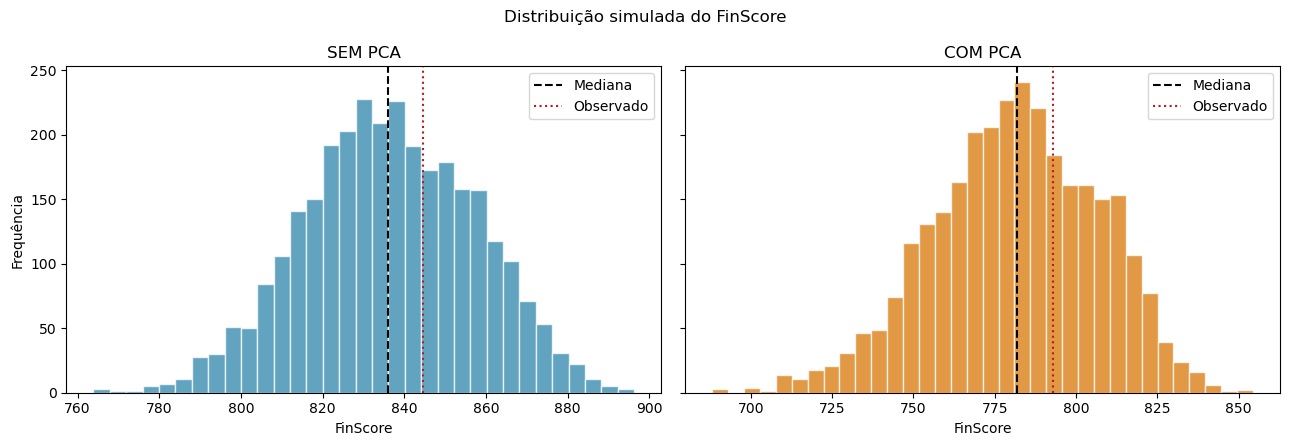

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, metodo, cor in zip(
    axes,
    ["sem_pca", "com_pca"],
    ["#2E86AB", "#D97706"],
):
    coluna = f"finscore_{metodo}"
    ax.hist(df_simulacoes[coluna], bins="fd", color=cor, alpha=0.75, edgecolor="white")
    ax.axvline(df_simulacoes[coluna].median(), color="black", linestyle="--", label="Mediana")
    ax.axvline(finscore_observado[coluna], color="#B91C1C", linestyle=":", label="Observado")
    ax.set_title(metodo.replace("_", " ").upper())
    ax.set_xlabel("FinScore")
    ax.legend()

axes[0].set_ylabel("Frequência")
fig.suptitle("Distribuição simulada do FinScore")
plt.tight_layout()
plt.show()

## 9. Exportação dos resultados

In [12]:
df_configuracao = pd.DataFrame({
    "parametro": ["planilha", "aba", "simulacoes", "semente", "delta_min", "delta_max", "peso_EO", "peso_FP"],
    "valor": [str(CAMINHO_PLANILHA), ABA_DADOS, NUM_SIMULACOES, SEMENTE,
              DELTA_MIN, DELTA_MAX, NUCLEUS_WEIGHTS["EO"], NUCLEUS_WEIGHTS["FP"]],
})

with pd.ExcelWriter(ARQUIVO_SAIDA, engine="openpyxl") as writer:
    df_resumo.to_excel(writer, "resumo", index=False)
    df_simulacoes.to_excel(writer, "simulacoes", index=False)
    df_contas_primarias.to_excel(writer, "contas_primarias", index=False)
    df_ajustes_importacao.to_excel(writer, "ajustes_importacao", index=False)
    df_contas_derivadas.to_excel(writer, "contas_derivadas", index=False)
    df_indices_observados.to_excel(writer, "indices_observados", index=False)
    df_notas_observadas.to_excel(writer, "notas_observadas", index=False)
    df_triangulares.to_excel(writer, "triangulares", index=False)
    df_validacoes.to_excel(writer, "validacoes", index=False)
    df_configuracao.to_excel(writer, "configuracao", index=False)

print(f"Resultados salvos em: {ARQUIVO_SAIDA.resolve()}")

C:\Users\ferna\AppData\Local\Temp\ipykernel_46840\4230198721.py:8: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  df_resumo.to_excel(writer, "resumo", index=False)
C:\Users\ferna\AppData\Local\Temp\ipykernel_46840\4230198721.py:9: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  df_simulacoes.to_excel(writer, "simulacoes", index=False)
C:\Users\ferna\AppData\Local\Temp\ipykernel_46840\4230198721.py:10: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  df_contas_primarias.to_excel(writer, "contas_primarias", index=False)
C:\Users\ferna\AppData\Local\Temp\ipykernel_46840\4230198721.py:11: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  df_a

Resultados salvos em: C:\Users\ferna\Documents\dev\Finscore\FinScore\V. 2 (Pudim)\algoritmos\resultados_finscore_v2.xlsx


## 10. Interpretação

- O resultado **sem PCA** usa uma régua fixa e torna a dispersão mais diretamente atribuível às contas simuladas.
- O resultado **com PCA** incorpora também a instabilidade dos pesos extraídos de apenas três exercícios.
- O Monte Carlo mede sensibilidade às premissas triangulares; ele não cria informação empírica nova nem elimina a escassez de dados.
- Alta proporção de flags indica que simular subtotais e componentes independentemente está produzindo trajetórias contábeis frágeis. Nesse caso, a próxima revisão deve reconstruir subtotais ou impor dependências explícitas.